### **Classification de sentiments sur des critiques de films**

## 1. Setup

In [6]:
from pathlib import Path
import sys

# Assume the repository is cloned into a directory named 'transformer-sentiment-analysis'
# within the current working directory.
PROJECT_ROOT = Path.cwd() / "transformer-sentiment-analysis"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

from src.transformer_modules.transformer_modules import *
from src.modeles.transformer_classifier import TransformerClassifier
import urllib.request
import tarfile
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


## 2. Configuration

In [7]:
import random
import numpy as np

SEED = 42
BATCH_SIZE = 32
MAX_LEN = 512
EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 1e-2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## 3. Donnees

### Chargement des donnees

Il s'agit d'un jeu de donnees pour la classification binaire des sentiments. Il y a 25 000 critiques de films tres polarisees pour l'entrainement et 25 000 pour les tests.

In [8]:
url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
output = DATA_DIR / "aclImdb_v1.tar.gz"

if not output.exists():
    urllib.request.urlretrieve(url, str(output))

if not (DATA_DIR / "aclImdb").exists():
    with tarfile.open(output, "r:gz") as f:
        f.extractall(path=str(DATA_DIR))


/tmp/ipykernel_2300/3952103052.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  f.extractall(path=str(DATA_DIR))


### Preparation des donnees

In [9]:
from src.utils.data import clean_text, create_vocab, load_and_prepare_imdb
from src.utils.train_and_evaluate import create_padding_mask

In [10]:
# preparation des donnees de train
max_len = MAX_LEN
X_train, y_train, vocab = load_and_prepare_imdb(
      str(DATA_DIR / "aclImdb" / "train"),
      vocab=None,
      max_len=max_len
)

# Création des DataLoaders
batch_size = BATCH_SIZE
train_dataset = TensorDataset(X_train, y_train.float())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Preparation des données de validation et de test
X_val_all, y_val_all, _ = load_and_prepare_imdb(str(DATA_DIR / "aclImdb" / "test"), vocab=vocab)
X_val, X_test, y_val, y_test = train_test_split(
        X_val_all,
        y_val_all,
        test_size=0.2,
        random_state=142,
        stratify=y_val_all
)

val_dataset = TensorDataset(X_val, y_val.float())
test_dataset = TensorDataset(X_test, y_test.float())

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [11]:
X_train.shape, y_train.shape,  X_test.shape, y_test.shape, X_val.shape, y_val.shape

(torch.Size([25000, 512]),
 torch.Size([25000]),
 torch.Size([5000, 256]),
 torch.Size([5000]),
 torch.Size([20000, 256]),
 torch.Size([20000]))

In [12]:
#  Configuration du device (CPU ou GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 4. Entrainement et evaluation

In [13]:
import torch.optim as optim
from torch.nn import BCEWithLogitsLoss

from src.utils.train_and_evaluate import (
    collect_predictions,
    evaluate,
    run_model_and_collect,
    test_metrics_with_time,
    train,
    train_model,
)


## 5. Modeles

### Transformer

In [29]:
results = []
histories = {}
criterion = torch.nn.BCEWithLogitsLoss()
epochs = EPOCHS

In [30]:
# Initialisation du modèle avec hyperparamètres raisonnables
# Note: Vous pouvez ajuster ces hyperparamètres en fonction de vos ressources et de vos besoins

d_model = 512      # Dimension des embeddings
N = 6             # 6 blocs encodeurs
h = 8              # 8 têtes d'attention
d_ff = 4 * d_model # Dimension feed-forward
dropout = 0.5      # Dropout pour régularisation

transformer = TransformerEncoderModel(
    vocab_size=len(vocab),
    d_model=d_model,
    N=N,
    h=h,
    d_ff=d_ff,
    dropout=dropout
).to(device)


transformer_model = TransformerClassifier(
    transformer,
    d_model=d_model,
    num_classes=1,
    pool_strategy="mean",
    dropout=dropout
).to(device)

nb_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f"Nombre de paramètres: {nb_params:,}")

opt_tr = torch.optim.AdamW(transformer_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
summary, history = run_model_and_collect(
    transformer_model, "Transformer",
    train_loader, val_loader, test_loader,
    opt_tr, criterion, device,
    epochs=epochs, use_mask=True
)
results.append(summary)
results[-1]["Nb de parametre"] = nb_params
histories["Transformer"] = history

Nombre de paramètres: 29,286,913
[Transformer] ====== Epoch 1/10 ====== | train_acc=0.7206 | val_acc=0.7914

[Transformer] ====== Epoch 2/10 ====== | train_acc=0.8343 | val_acc=0.8373

[Transformer] ====== Epoch 3/10 ====== | train_acc=0.8601 | val_acc=0.8490

[Transformer] ====== Epoch 4/10 ====== | train_acc=0.8758 | val_acc=0.8560

[Transformer] ====== Epoch 5/10 ====== | train_acc=0.8883 | val_acc=0.8595

[Transformer] ====== Epoch 6/10 ====== | train_acc=0.8985 | val_acc=0.8620

[Transformer] ====== Epoch 7/10 ====== | train_acc=0.9055 | val_acc=0.8597

[Transformer] ====== Epoch 8/10 ====== | train_acc=0.9080 | val_acc=0.8647

[Transformer] ====== Epoch 9/10 ====== | train_acc=0.9156 | val_acc=0.8623

[Transformer] ====== Epoch 10/10 ====== | train_acc=0.9224 | val_acc=0.8612



### GRU

In [31]:
from src.modeles.rnn_classifier import RNNClassifier

embeding_dim = 512 # Dimension des embeddings
hidden_dim = 128 # Dimension des états cachés
num_layers = 3 # Nombre de couches
bidirectional = True # Utilisation d'un RNN bidirectionnel
dropout = 0.5 # Taux de dropout

gru_model = RNNClassifier(
    vocab_size = len(vocab),
    embed_dim = embeding_dim,
    hidden_dim = hidden_dim,
    num_layers = num_layers,
    bidirectional = bidirectional,
    dropout = dropout,
    pad_idx = 0,
    rnn_type = "gru"
).to(device)

nb_params_gru = sum(p.numel() for p in gru_model.parameters() if p.requires_grad)
print(f"Nombre de paramètres: {nb_params_gru:,}")
#train_model(gru_model,train_loader,test_loader,optimizer=None,criterion=None,device=device,epochs=10)

opt_gru = torch.optim.AdamW(gru_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
summary, history = run_model_and_collect(
    gru_model, "GRU",
    train_loader, val_loader, test_loader,
    opt_gru, criterion, device,
    epochs=epochs, use_mask=True
)
results.append(summary)
results[-1]["Nb de parametre"] = nb_params_gru
histories["GRU"] = history

Nombre de paramètres: 11,358,977
[GRU] ====== Epoch 1/10 ====== | train_acc=0.6984 | val_acc=0.8013

[GRU] ====== Epoch 2/10 ====== | train_acc=0.8651 | val_acc=0.8490

[GRU] ====== Epoch 3/10 ====== | train_acc=0.9170 | val_acc=0.8655

[GRU] ====== Epoch 4/10 ====== | train_acc=0.9478 | val_acc=0.8569

[GRU] ====== Epoch 5/10 ====== | train_acc=0.9675 | val_acc=0.8673

[GRU] ====== Epoch 6/10 ====== | train_acc=0.9795 | val_acc=0.8603

[GRU] ====== Epoch 7/10 ====== | train_acc=0.9874 | val_acc=0.8664

[GRU] ====== Epoch 8/10 ====== | train_acc=0.9910 | val_acc=0.8629

[GRU] ====== Epoch 9/10 ====== | train_acc=0.9914 | val_acc=0.8657

[GRU] ====== Epoch 10/10 ====== | train_acc=0.9919 | val_acc=0.8600



### LSTM

In [32]:
lstm_model = RNNClassifier(
    vocab_size = len(vocab),
    embed_dim = embeding_dim,
    hidden_dim = hidden_dim,
    num_layers = num_layers,
    bidirectional = bidirectional,
    dropout = dropout,
    pad_idx = 0,
    rnn_type = "lstm"
).to(device)

nb_params_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Nombre de paramètres LSTM: {nb_params_lstm:,}")

#train_model(gru_model, train_loader, test_loader, None, None, device, epochs=10)

opt_lstm = torch.optim.AdamW(lstm_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
summary, history = run_model_and_collect(
    lstm_model, "LSTM",
    train_loader, val_loader, test_loader,
    opt_lstm, criterion, device,
    epochs=epochs, use_mask=True
)
results.append(summary)
results[-1]["Nb de parametre"] = nb_params_lstm
histories["LSTM"] = history

Nombre de paramètres LSTM: 11,720,961
[LSTM] ====== Epoch 1/10 ====== | train_acc=0.7188 | val_acc=0.7417

[LSTM] ====== Epoch 2/10 ====== | train_acc=0.8619 | val_acc=0.8438

[LSTM] ====== Epoch 3/10 ====== | train_acc=0.9052 | val_acc=0.8557

[LSTM] ====== Epoch 4/10 ====== | train_acc=0.9350 | val_acc=0.8548

[LSTM] ====== Epoch 5/10 ====== | train_acc=0.9546 | val_acc=0.8488

[LSTM] ====== Epoch 6/10 ====== | train_acc=0.9725 | val_acc=0.8651

[LSTM] ====== Epoch 7/10 ====== | train_acc=0.9814 | val_acc=0.8572

[LSTM] ====== Epoch 8/10 ====== | train_acc=0.9864 | val_acc=0.8584

[LSTM] ====== Epoch 9/10 ====== | train_acc=0.9891 | val_acc=0.8583

[LSTM] ====== Epoch 10/10 ====== | train_acc=0.9905 | val_acc=0.8425



### CNN

In [33]:
from src.modeles.cnn_classifier import TextCNNClassifier

cnn_model = TextCNNClassifier(
    vocab_size=len(vocab),
    embed_dim=embeding_dim,
    kernel_sizes=[3,4,5],
    num_filters=100,
    dropout=dropout,
    pad_idx=0
).to(device)

nb_params_cnn = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Nombre de paramètres CNN: {nb_params_cnn:,}")

#train_model(cnn_model, train_loader, test_loader, None, None, device, epochs=10)

opt_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
summary, history = run_model_and_collect(
    cnn_model, "TextCNN",
    train_loader, val_loader, test_loader,
    optimizer=opt_cnn,
    criterion=criterion,
    device=device,
    epochs=epochs,
    use_mask=False
)
results.append(summary)
results[-1]["Nb de parametre"] = nb_params_cnn
histories["TextCNN"] = history

Nombre de paramètres CNN: 10,900,001
[TextCNN] ====== Epoch 1/10 ====== | train_acc=0.6388 | val_acc=0.7739

[TextCNN] ====== Epoch 2/10 ====== | train_acc=0.7643 | val_acc=0.8169

[TextCNN] ====== Epoch 3/10 ====== | train_acc=0.8072 | val_acc=0.8396

[TextCNN] ====== Epoch 4/10 ====== | train_acc=0.8439 | val_acc=0.8479

[TextCNN] ====== Epoch 5/10 ====== | train_acc=0.8703 | val_acc=0.8619

[TextCNN] ====== Epoch 6/10 ====== | train_acc=0.8943 | val_acc=0.8667

[TextCNN] ====== Epoch 7/10 ====== | train_acc=0.9132 | val_acc=0.8691

[TextCNN] ====== Epoch 8/10 ====== | train_acc=0.9363 | val_acc=0.8691

[TextCNN] ====== Epoch 9/10 ====== | train_acc=0.9479 | val_acc=0.8692

[TextCNN] ====== Epoch 10/10 ====== | train_acc=0.9597 | val_acc=0.8663



## 6. Resultats

### Tableau recapitulatif

In [34]:
import pandas as pd
df = pd.DataFrame(results)
df

,Model,Test Acc,Test F1,Test ROC-AUC,Train Time (s),Test Eval Time (s),Nb de parametre
0,Transformer,0.871,0.874,0.943,9051.608,23.312,29286913
1,GRU,0.872,0.867,0.941,851.047,3.335,11358977
2,LSTM,0.845,0.833,0.930,874.906,2.692,11720961
3,TextCNN,0.878,0.878,0.951,305.449,0.765,10900001


### Courbes d'apprentissage

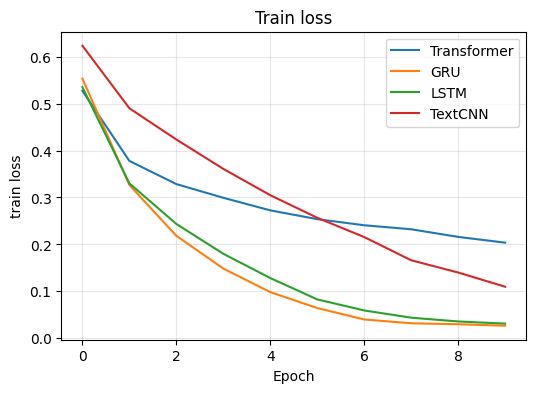

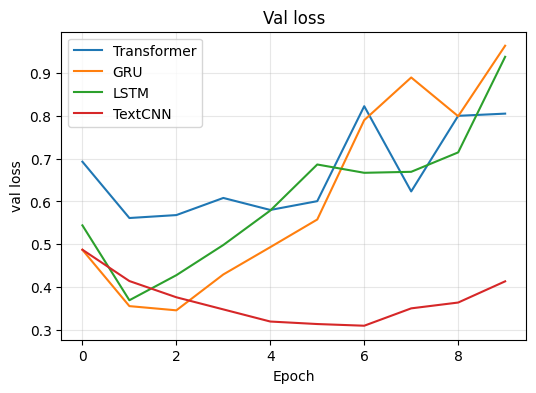

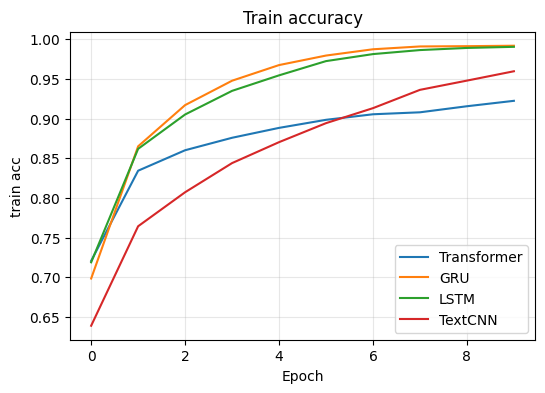

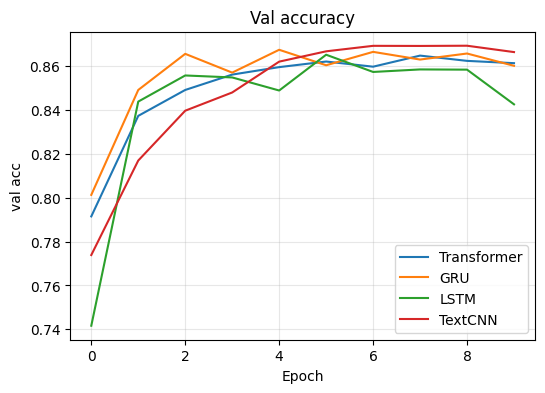

In [35]:
import matplotlib.pyplot as plt

def plot_history(histories, metric, title):
    plt.figure(figsize=(6, 4))
    for name, hist in histories.items():
        plt.plot(hist[metric], label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " "))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_history(histories, "train_loss", "Train loss")
plot_history(histories, "val_loss", "Val loss")
plot_history(histories, "train_acc", "Train accuracy")
plot_history(histories, "val_acc", "Val accuracy")


Les courbes de train loss  montrent que le Transformer converge 
plus lentement que les autres modèles, cohérent avec sa complexité plus élevée. 
Le GRU et le LSTM atteignent rapidement une loss proche de zéro sur l'ensemble d'entraînement,
signe d'une forte capacité de mémorisation. En validation, 
TextCNN présente la loss la plus basse et la plus stable, tandis que GRU, LSTM et Transformer 
montrent une remontée progressive, indiquant un certain surapprentissage .
En accuracy , les quatre modèles 
convergent vers des performances proches sur l'ensemble de validation ($\approx 0.86$), 
TextCNN conservant un léger avantage.

### Courbes ROC et Precision-Recall

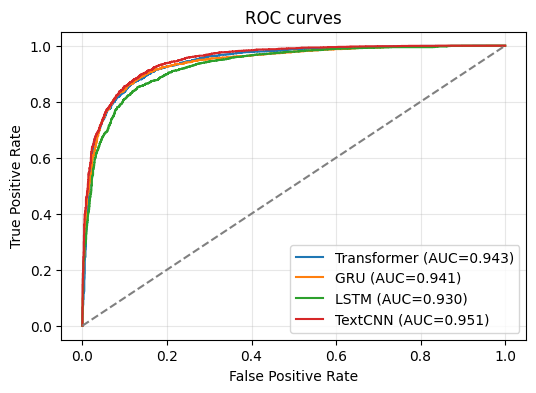

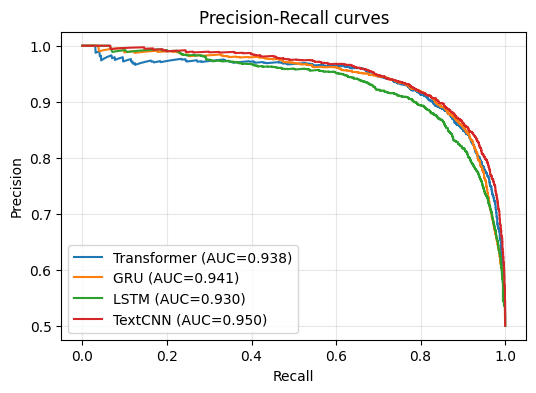

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay, auc, confusion_matrix, precision_recall_curve, roc_curve

models_info = [
    ("Transformer", transformer_model, True),
    ("GRU", gru_model, True),
    ("LSTM", lstm_model, True),
    ("TextCNN", cnn_model, False),
]

preds = {}
for name, model, use_mask in models_info:
    y_true, y_prob, y_pred = collect_predictions(model, test_loader, device, use_mask=use_mask)
    preds[name] = {"y_true": y_true, "y_prob": y_prob, "y_pred": y_pred}

plt.figure(figsize=(6, 4))
for name, p in preds.items():
    fpr, tpr, _ = roc_curve(p["y_true"], p["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
for name, p in preds.items():
    precision, recall, _ = precision_recall_curve(p["y_true"], p["y_prob"])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.3f})")
plt.title("Precision-Recall curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Les courbes ROC  confirment la compétitivité du Transformer 
en discrimination (AUC $=0.943$), proche de TextCNN (AUC $=0.951$) et supérieur au GRU 
(AUC $=0.941$) et au LSTM (AUC $=0.930$). 
Les courbes Précision-Rappel  traduisent un constat similaire : 
TextCNN obtient la meilleure aire sous la courbe (AUC $=0.950$), 
le Transformer reste solide $(AUC=0.938)$, tandis que LSTM accuse le plus grand recul 
(AUC $=0.930$). Ces résultats montrent que tous les modèles ont une bonne capacité de 
discrimination, mais que TextCNN et le Transformer dominent légèrement sur les seuils 
de décision élevés.

### Matrices de confusion

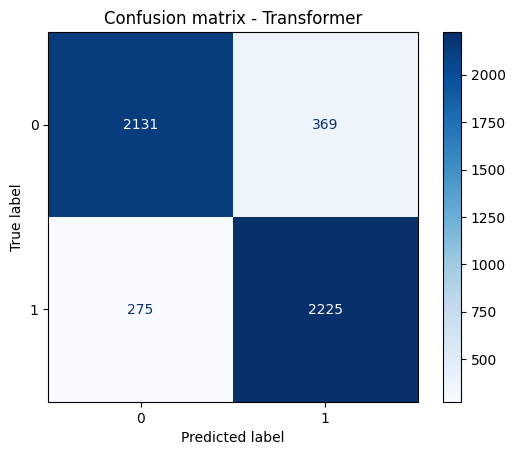

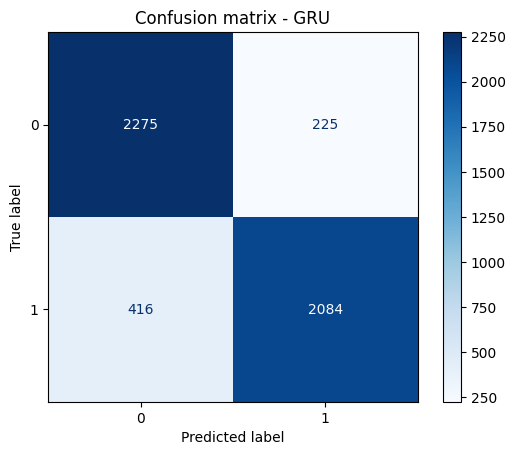

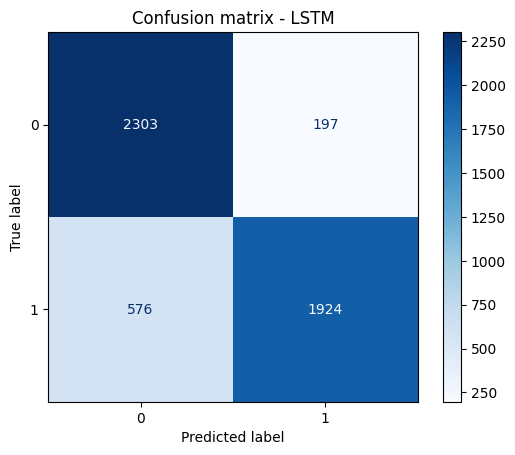

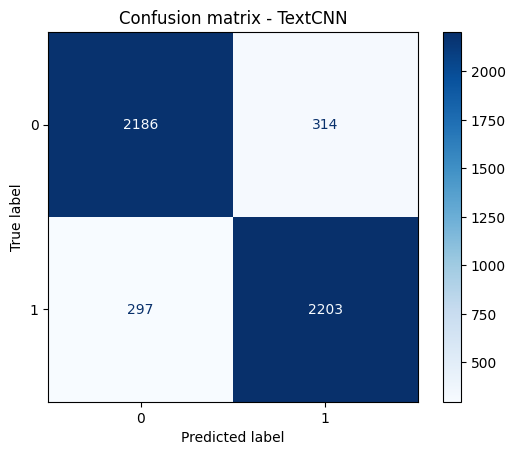

In [37]:
for name, p in preds.items():
    cm = confusion_matrix(p["y_true"], p["y_pred"])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion matrix - {name}")
    plt.show()


Les matrices de confusion 
révèlent des profils d'erreur distincts. TextCNN présente la répartition la plus 
équilibrée entre faux positifs (314) et faux négatifs (297). Le Transformer génère 
davantage de faux positifs (369) que de faux négatifs (275), ce qui traduit une 
légère tendance à prédire la classe positive. Le GRU et le LSTM présentent l'effet 
inverse : un nombre élevé de faux négatifs (respectivement 416 et 576), indiquant 
une plus grande difficulté à détecter les avis positifs. Dans l'ensemble, aucun 
modèle ne montre de biais systématique majeur, mais LSTM accuse le déséquilibre 
le plus prononcé.

## 7. Sauvegarde et chargement

In [38]:
# Sauvegarder le modèle Transformer
torch.save(transformer_model.state_dict(), MODELS_DIR / "transformer_sentiment.pt")


In [39]:
# Recharger le modèle
model = TransformerClassifier(
    transformer,
    d_model=d_model,
    num_classes=1,
    pool_strategy="mean",
    dropout=dropout
).to(device)
model.load_state_dict(torch.load(MODELS_DIR / "transformer_sentiment.pt", map_location="cpu"))
model.eval()


TransformerClassifier(
  (transformer): TransformerEncoderModel(
    (embed): Embeddings(
      (embedding): Embedding(20000, 512)
    )
    (pos): PositionalEncoding(
      (dropout): Dropout(p=0.5, inplace=False)
    )
    (encoder): Encoder(
      (blocks): ModuleList(
        (0-5): 6 x TransformerEncoderBlock(
          (attention): MultiHeadedAttention(
            (linears): ModuleList(
              (0-3): 4 x Linear(in_features=512, out_features=512, bias=True)
            )
            (dropout): Dropout(p=0.5, inplace=False)
          )
          (feed_forward): PositionwiseFeedForward(
            (W1): Linear(in_features=512, out_features=2048, bias=True)
            (W2): Linear(in_features=2048, out_features=512, bias=True)
            (dropout): Dropout(p=0.5, inplace=False)
            (activation): ReLU()
          )
          (residual_blocks): ModuleList(
            (0-1): 2 x SubLayerConnection(
              (norm): LayerNorm()
              (dropout): Dropout(p=